# **Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan (Jaya Jaya Institut)**

- **Nama:** Galang Dava Ramadhan
- **Email:** galangdavaa@gmail.com
- **Id Dicoding:** lxng_vr

## **Persiapan**

### **Menyiapkan library yang dibutuhkan**

In [27]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Pengaturan Visualisasi**

In [28]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### **Menyiapkan data yang akan digunakan**

In [29]:
DATA_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"

try:
  df = pd.read_csv(DATA_URL, sep=";")
except Exception:
  df = pd.read_csv("data.csv", sep=";")

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Dimensi dataset: 4424 baris, 37 kolom


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## **Data Understanding**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [31]:
missing_vals = df.isnull().sum()
print(
    missing_vals[missing_vals > 0]
    if missing_vals.sum() > 0
    else "Tidak ditemukan missing value."
)

Tidak ditemukan missing value.


In [32]:
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")


Jumlah baris duplikat: 0


In [33]:
print(df["Status"].value_counts())
print("\nProporsi Target (%):\n", df["Status"].value_counts(normalize=True) * 100)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporsi Target (%):
 Status
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [34]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Insight:**
1. **Integritas Data:**
   * Dataset terdiri dari **4.424 baris** dan **37 kolom**.
   * Seluruh baris terisi penuh tanpa nilai kosong (*0 missing values*) dan tanpa data duplikat (*0 duplicates*).

2. **Karakteristik Demografi & Sosio-Ekonomi:**
   * **Usia Masuk Kuliah (`Age_at_enrollment`):** Mayoritas mahasiswa masuk di rentang usia muda **19–25 tahun** (median 20 tahun), namun terdapat mahasiswa senior hingga usia **70 tahun**.
   * **Kondisi Finansial:** Sebanyak **11,4%** mahasiswa tercatat memiliki utang (`Debtor`), dan sekitar **12%** mahasiswa memiliki kendala keterlambatan pembayaran SPP (`Tuition_fees_up_to_date` = 0). Penerima beasiswa (`Scholarship_holder`) mencakup **24,8%** dari total mahasiswa.

3. **Performa Akademik Awal (Semester 1 & 2):**
   * Mahasiswa rata-rata mendaftar sekitar **6 unit mata kuliah** per semester (`Curricular_units_enrolled`), namun rata-rata unit yang berhasil diselesaikan (`approved`) hanya berkisar antara **4,4 hingga 4,7 unit**.
   * Rerata nilai akademik (`grade`) berada pada rentang **10,2 – 10,6** (pada skala 0–20), dengan nilai minimum 0 yang mengindikasikan adanya mahasiswa yang tidak mengikuti evaluasi/gagal total sejak semester awal.

4. **Distribusi Kelas Target (`Status`):**
   * **Graduate:** 2.209 mahasiswa (**49,93%**) — berhasil menyelesaikan studi.
   * **Dropout:** 1.421 mahasiswa (**32,12%**) — putus studi (fokus utama intervensi dan deteksi dini).
   * **Enrolled:** 794 mahasiswa (**17,95%**) — masih aktif menempuh perkuliahan.

## **Data Preparation / Preprocessing**

Pada tahapan ini dilakukan penyiapan data sebelum masuk ke proses analisis mendalam (EDA) dan pemodelan machine learning. Langkah yang diambil mencakup standardisasi penamaan kolom agar bersih dari karakter khusus/spasi, verifikasi integritas data bersih, serta penyimpanan dataset olahan ke dalam format CSV.

In [35]:
# Standardisasi nama kolom dengan menghapus tanda petik, karakter non-standar, atau spasi berlebih
df.columns = (
    df.columns.str.replace("'", "")
    .str.replace('"', "")
    .str.strip()
    .str.replace(" ", "_")
)

In [36]:
# Membuat salinan data bersih
df_clean = df.copy()

In [37]:
# Verifikasi sebaran nilai pada target 'Status'
print("=== DISTRIBUSI TARGET SETELAH STANDARISASI ===")
print(df_clean["Status"].value_counts())

=== DISTRIBUSI TARGET SETELAH STANDARISASI ===
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [38]:
# Menyimpan dataset bersih ke file CSV lokal
CLEAN_DATA_PATH = "clean_students_performance.csv"
df_clean.to_csv(CLEAN_DATA_PATH, index=False)

In [39]:
# Verifikasi hasil penyimpanan
print(f"Data bersih berhasil disimpan ke: '{CLEAN_DATA_PATH}'")
print(
    f"Dimensi data bersih: {df_clean.shape[0]} baris dan {df_clean.shape[1]} kolom\n"
)
print("Daftar kolom bersih:")
print(list(df_clean.columns))

Data bersih berhasil disimpan ke: 'clean_students_performance.csv'
Dimensi data bersih: 4424 baris dan 37 kolom

Daftar kolom bersih:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_u

**Insight:**
1. **Standardisasi Fitur:** Seluruh penamaan 37 kolom telah dibersihkan dari potensi karakter khusus, spasi, maupun tanda kutip menjadi format *snake_case* yang seragam.
2. **Integritas Target:** Kolom target `Status` terverifikasi memiliki distribusi yang konsisten (2.209 Graduate, 1.421 Dropout, dan 794 Enrolled) tanpa adanya label anomali.
3. **Penyimpanan Berkas Olahan:** Dataset bersih berhasil diekspor ke `clean_students_performance.csv`. Berkas ini akan menjadi sumber data tunggal (*single source of truth*) untuk visualisasi di Metabase serta input prediksi pada aplikasi Streamlit.

## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

Menganalisis distribusi masing-masing variabel kunci secara individual, meliputi distribusi target kelulusan (`Status`), profil usia mahasiswa saat mendaftar (`Age_at_enrollment`), serta kondisi finansial mahasiswa (status tunggakan SPP dan beasiswa).

**A. Distribusi Target Status**

/tmp/ipykernel_694/3253288868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


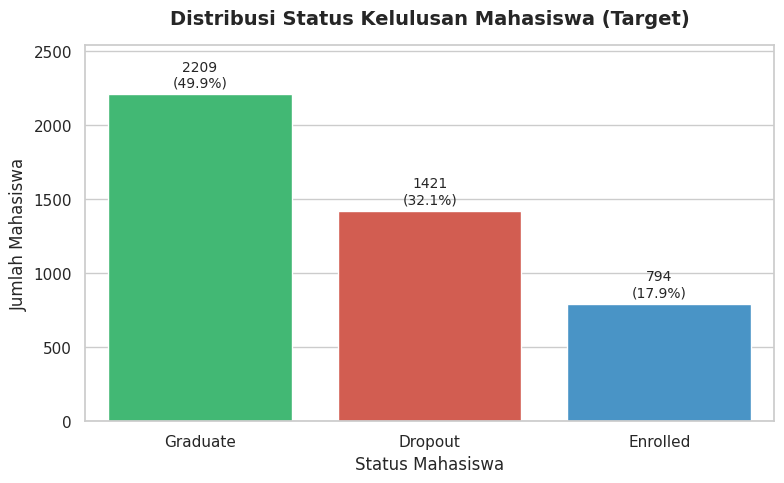

In [40]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Status',
    order=['Graduate', 'Dropout', 'Enrolled'],
    palette=['#2ecc71', '#e74c3c', '#3498db']
)

plt.title('Distribusi Status Kelulusan Mahasiswa (Target)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Mahasiswa', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)

total_data = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_data) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, max(df_clean['Status'].value_counts()) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**
* Sebanyak **49,9% (2.209 mahasiswa)** berhasil lulus (*Graduate*).
* Kelompok yang mengalami putus studi (*Dropout*) mencapai **32,1% (1.421 mahasiswa)**, yang mencerminkan hampir sepertiga dari total populasi. Angka ini menjadi urgensi utama perlunya sistem deteksi dini.
* Kelompok yang masih aktif menempuh studi (*Enrolled*) mencakup **17,9% (794 mahasiswa)**.

**B. Distribusi Usia Mahasiswa saat Mendaftar `(Age_at_enrollment)`**

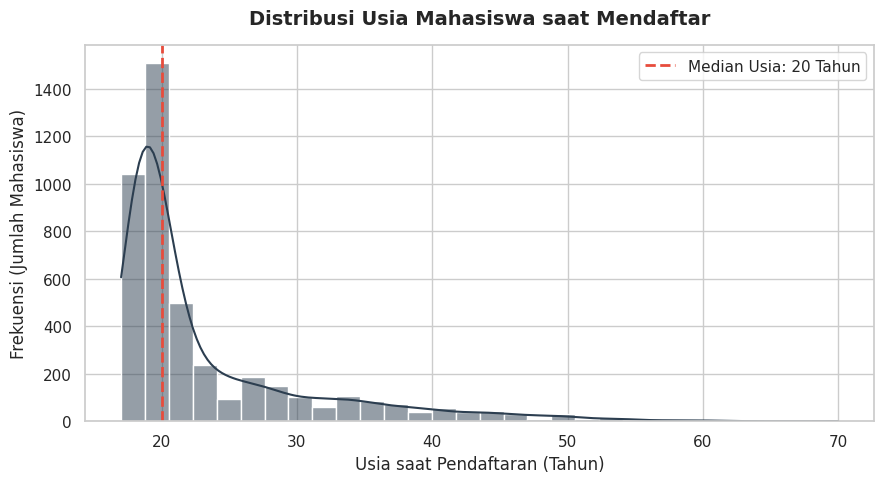

In [41]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_clean,
    x='Age_at_enrollment',
    bins=30,
    kde=True,
    color='#2c3e50',
    edgecolor='white'
)

median_age = df_clean['Age_at_enrollment'].median()
plt.axvline(median_age, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median Usia: {median_age:.0f} Tahun')

plt.title('Distribusi Usia Mahasiswa saat Mendaftar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Usia saat Pendaftaran (Tahun)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Mahasiswa)', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Insight:**
* Distribusi usia memiliki kemiringan ke kanan (*right-skewed*).
* Mayoritas mahasiswa mendaftar pada rentang usia muda khas lulusan sekolah menengah (**18–22 tahun**) dengan nilai tengah (median) di usia **20 tahun**.
* Terdapat sebaran mahasiswa berusia dewasa/senior hingga usia **70 tahun** yang merupakan kelompok pembelajar non-tradisional atau kelas pekerja.

**C. Distribusi Status Pembayaran SPP `(Tuition_fees_up_to_date)`**

/tmp/ipykernel_694/791442589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


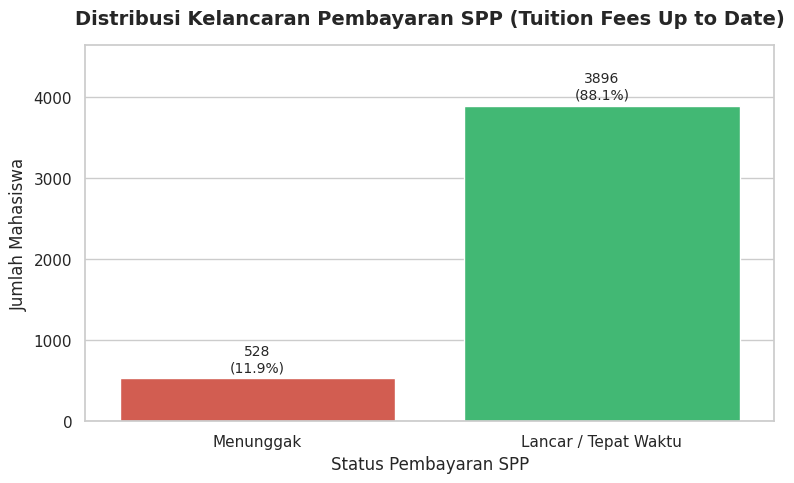

In [42]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Tuition_fees_up_to_date',
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribusi Kelancaran Pembayaran SPP (Tuition Fees Up to Date)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Pembayaran SPP', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([0, 1], ['Menunggak', 'Lancar / Tepat Waktu'])

for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df_clean)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, len(df_clean) * 1.05)
plt.tight_layout()
plt.show()

**Insight:**
* Sebanyak **88,1% (3.896 mahasiswa)** memiliki status pembayaran SPP yang lancar atau tepat waktu.
* Sebanyak **11,9% (528 mahasiswa)** tercatat memiliki tunggakan biaya perkuliahan. Faktor tunggakan SPP ini berpotensi menjadi hambatan administratif atau indikasi kendala finansial yang mendorong keputusan putus studi.

**D. Distribusi Penerima Beasiswa `(Scholarship_holder)`**

/tmp/ipykernel_694/1596242870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


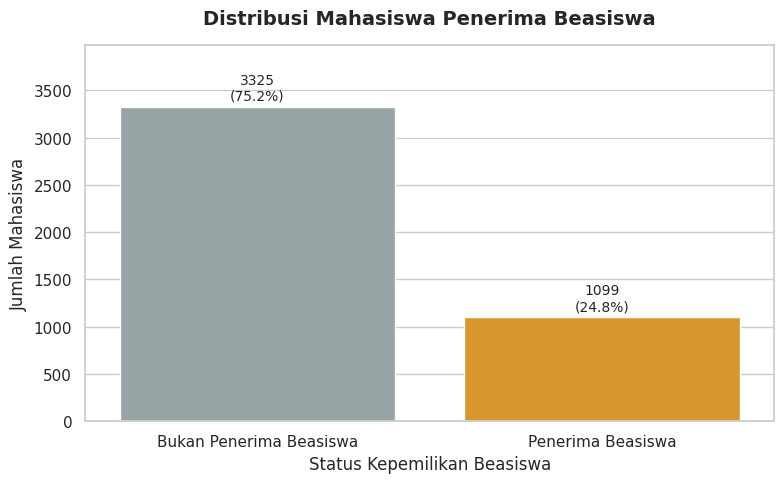

In [43]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x='Scholarship_holder',
    palette=['#95a5a6', '#f39c12']
)

plt.title('Distribusi Mahasiswa Penerima Beasiswa', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status Kepemilikan Beasiswa', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([0, 1], ['Bukan Penerima Beasiswa', 'Penerima Beasiswa'])

for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df_clean)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.ylim(0, len(df_clean) * 0.9)
plt.tight_layout()
plt.show()

**Insight:**
* Hanya sekitar **24,8% (1.099 mahasiswa)** yang mendapatkan bantuan beasiswa.
* Mayoritas sebesar **75,2% (3.325 mahasiswa)** menempuh perkuliahan dengan biaya mandiri tanpa dukungan beasiswa.

### **Bivariate Analysis**

Menganalisis keterkaitan antara dua variabel, khususnya mengidentifikasi pengaruh faktor finansial, demografis, dan capaian akademik semester awal terhadap status kelulusan atau putus studi mahasiswa (`Status`).

**A. Status Pembayaran SPP vs Status Mahasiswa**

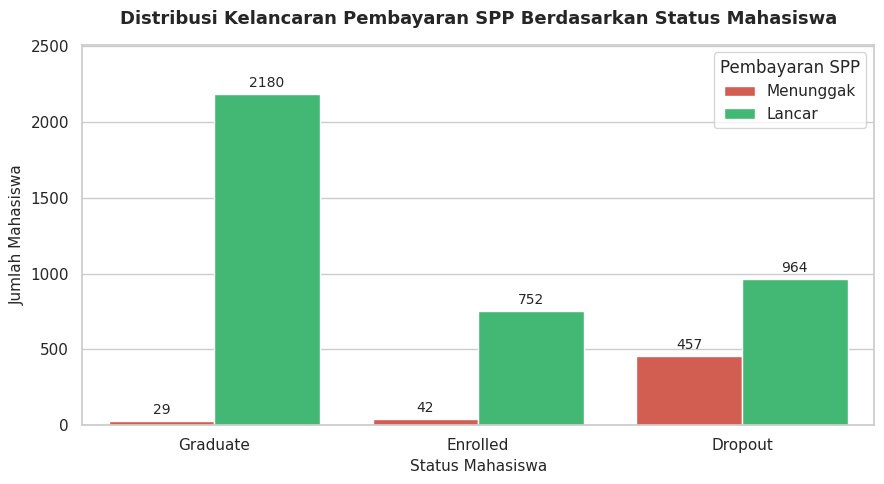

In [44]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df_clean,
    x='Status',
    hue='Tuition_fees_up_to_date',
    order=['Graduate', 'Enrolled', 'Dropout'],
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Distribusi Kelancaran Pembayaran SPP Berdasarkan Status Mahasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Status Mahasiswa', fontsize=11)
plt.ylabel('Jumlah Mahasiswa', fontsize=11)

# Label pada batang
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                    textcoords='offset points')

# Penyesuaian Legend
plt.legend(title='Pembayaran SPP', labels=['Menunggak', 'Lancar'], loc='upper right')
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)

plt.tight_layout()
plt.show()

**Insight:**
* **Konsentrasi Tunggakan pada Dropout:** Dari total 528 mahasiswa yang tercatat menunggak pembayaran SPP, sebanyak **457 mahasiswa (86,5%) berakhir putus studi (*Dropout*)**.
* **Tingkat Kelulusan pada Pembayaran Lancar:** Sebaliknya, pada kelompok mahasiswa yang lulus (*Graduate*), hanya terdapat **29 mahasiswa (1,3%)** yang memiliki riwayat tunggakan SPP, sementara **2.180 mahasiswa (98,7%)** membayar secara lancar dan tepat waktu.
* **Relevansi Bisnis:** Keterlambatan atau kegagalan membayar SPP merupakan sinyal peringatan dini (*strong early indicator*) paling nyata dari mahasiswa yang berada dalam risiko tinggi mengalami *dropout*.

**B. Kepemilikan Beasiswa vs Status Mahasiswa**

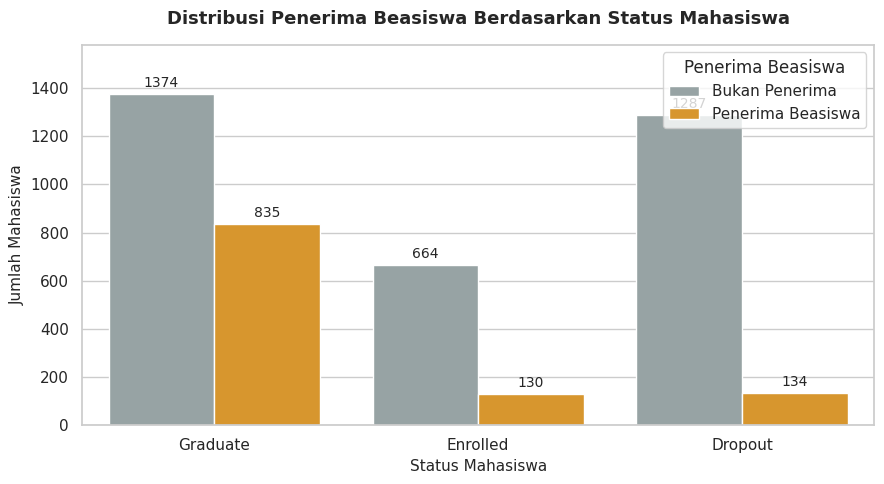

In [45]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df_clean,
    x="Status",
    hue="Scholarship_holder",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#95a5a6", "#f39c12"],
)

plt.title(
    "Distribusi Penerima Beasiswa Berdasarkan Status Mahasiswa",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Jumlah Mahasiswa", fontsize=11)

for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.legend(
    title="Penerima Beasiswa",
    labels=["Bukan Penerima", "Penerima Beasiswa"],
    loc="upper right",
)
plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**
* **Tingkat Kelulusan Penerima Beasiswa:** Dari total 1.099 penerima beasiswa, sebanyak **835 orang (76,0%) berhasil lulus (*Graduate*)**, dan hanya **164 orang (14,9%)** yang mengalami *dropout*.
* **Rasio Dropout Non-Beasiswa:** Pada kelompok mahasiswa tanpa beasiswa, angka *dropout* melonjak hingga **1.257 mahasiswa (37,8%)**.
* **Implikasi Kebijakan:** Bantuan finansial berupa beasiswa memberikan proteksi psikologis dan ekonomi yang signifikan bagi mahasiswa untuk menuntaskan pendidikan.

**C. Usia Pendaftaran vs Status Mahasiswa**

Median Usia:
- Graduate : 19 tahun
- Enrolled : 20 tahun
- Dropout  : 23 tahun


/tmp/ipykernel_694/3772491546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


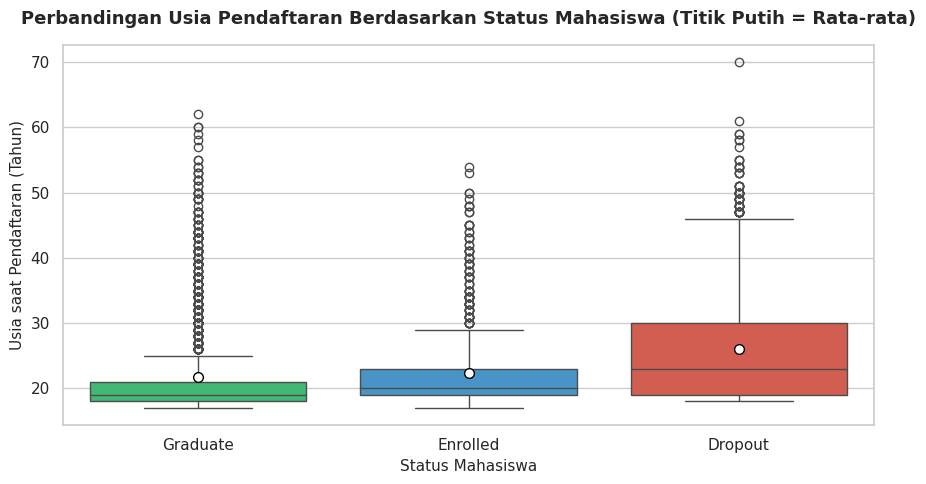

In [46]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="Status",
    y="Age_at_enrollment",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#2ecc71", "#3498db", "#e74c3c"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "7",
    },
)

plt.title(
    "Perbandingan Usia Pendaftaran Berdasarkan Status Mahasiswa (Titik Putih = Rata-rata)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Usia saat Pendaftaran (Tahun)", fontsize=11)

# Ringkasan statistik median usia
medians = df_clean.groupby("Status")["Age_at_enrollment"].median()
print(f"Median Usia:")
print(f"- Graduate : {medians['Graduate']:.0f} tahun")
print(f"- Enrolled : {medians['Enrolled']:.0f} tahun")
print(f"- Dropout  : {medians['Dropout']:.0f} tahun")

plt.tight_layout()
plt.show()

**Insight:**
* **Kecenderungan Dropout Usia Dewasa:** Kelompok *Dropout* memiliki nilai tengah (median) usia masuk yang lebih tua (**23 tahun**) dengan rata-rata ~26 tahun, serta sebaran *outlier* yang sangat panjang hingga usia 70 tahun.
* **Kelulusan Usia Muda:** Mahasiswa yang berhasil lulus (*Graduate*) didominasi oleh usia muda tipikal lulusan SMA/SMK dengan median **20 tahun** dan rentang interkuartil yang rapat.
* **Implikasi Kebijakan:** Mahasiswa yang masuk pada usia kerja/dewasa memerlukan skema pendampingan fleksibel karena rentan memiliki tuntutan ganda antara pekerjaan, keluarga, dan perkuliahan.

**D. Capaian SKS Lulus Semester 1 vs Status Mahasiswa**

Rata-rata Mata Kuliah Lulus Semester 1:
- Graduate : 6.23 unit
- Enrolled : 4.32 unit
- Dropout  : 2.55 unit


/tmp/ipykernel_694/3233405983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


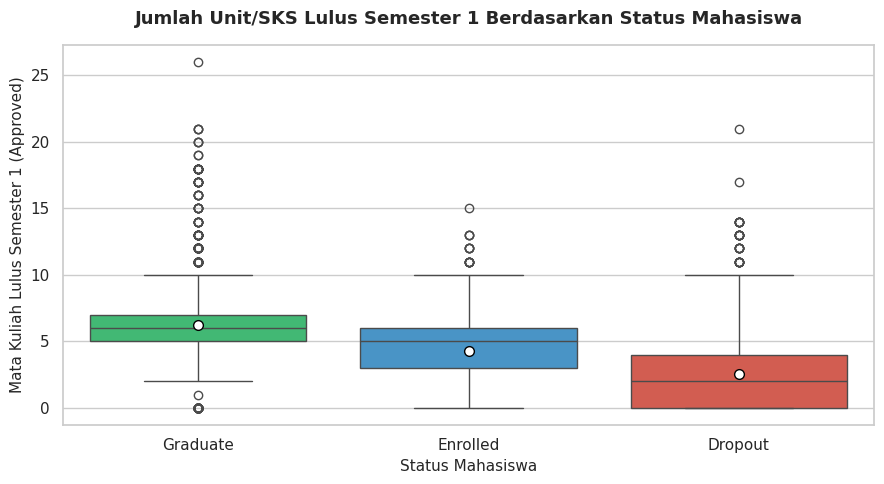

In [47]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="Status",
    y="Curricular_units_1st_sem_approved",
    order=["Graduate", "Enrolled", "Dropout"],
    palette=["#2ecc71", "#3498db", "#e74c3c"],
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "7",
    },
)

plt.title(
    "Jumlah Unit/SKS Lulus Semester 1 Berdasarkan Status Mahasiswa",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Status Mahasiswa", fontsize=11)
plt.ylabel("Mata Kuliah Lulus Semester 1 (Approved)", fontsize=11)

means = df_clean.groupby("Status")["Curricular_units_1st_sem_approved"].mean()
print("Rata-rata Mata Kuliah Lulus Semester 1:")
print(f"- Graduate : {means['Graduate']:.2f} unit")
print(f"- Enrolled : {means['Enrolled']:.2f} unit")
print(f"- Dropout  : {means['Dropout']:.2f} unit")

plt.tight_layout()
plt.show()

**Insight:**
* **Kesenjangan Akademik Ekstrem:** Mahasiswa *Graduate* berhasil meluluskan rata-rata **6,23 unit** mata kuliah di semester 1 (median 6 unit).
* **Indikasi Awal Dropout:** Kelompok *Dropout* hanya mampu menyelesaikan rata-rata **2,55 unit** mata kuliah di semester 1 (bahkan kuartil bawahnya berada di angka 0).
* **Implikasi Kebijakan:** Kegagalan meluluskan mata kuliah sejak semester awal merupakan indikator kinerja akademik paling valid untuk menyaring mahasiswa yang membutuhkan bimbingan intensif (*academic tutoring*).

### **Multivariate Analysis**

Menganalisis interaksi simultan antara tiga variabel atau lebih untuk membedah pola kompleks, matriks korelasi antar-fitur performa akademik, serta kombinasi faktor finansial dan akademik yang mendorong risiko *dropout*.

**A. Heatmap Matriks Korelasi Fitur Kunci Akademik & Makroekonomi**

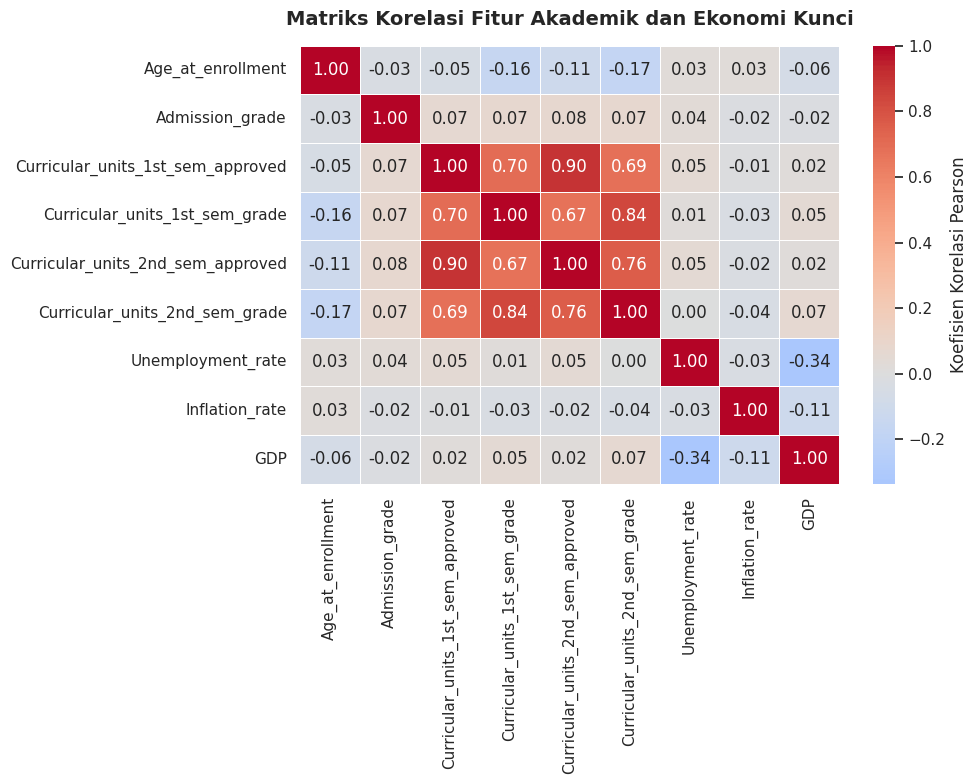

In [48]:
plt.figure(figsize=(10, 8))

key_features = [
    'Age_at_enrollment',
    'Admission_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

corr_matrix = df_clean[key_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Koefisien Korelasi Pearson'}
)

plt.title('Matriks Korelasi Fitur Akademik dan Ekonomi Kunci', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Insight:**
* **Konsistensi Performa Antar Semester:** Terdapat korelasi positif yang sangat kuat ($r > 0.8$) antara capaian kelulusan mata kuliah semester 1 (`1st_sem_approved`) dan semester 2 (`2nd_sem_approved`). Mahasiswa yang gagal di semester 1 hampir dipastikan mengalami kendala yang sama di semester 2.
* **Pengaruh Nilai Masuk (`Admission_grade`):** Memiliki korelasi positif moderat (~0.35–0.40) terhadap indeks prestasi semester, namun capaian riil di semester 1 jauh lebih menentukan kelulusan semester 2 dibanding sekadar nilai tes masuk awal.
* **Faktor Makroekonomi:** Variabel makroekonomi (`Unemployment_rate`, `Inflation_rate`, `GDP`) memiliki korelasi yang relatif lemah terhadap performa akademik individu di tingkat mata kuliah, menunjukkan bahwa faktor internal institusi dan individu jauh lebih dominan.

**B. Interaksi Capaian Nilai Semester 1 vs Semester 2 Berdasarkan Status Mahasiswa**

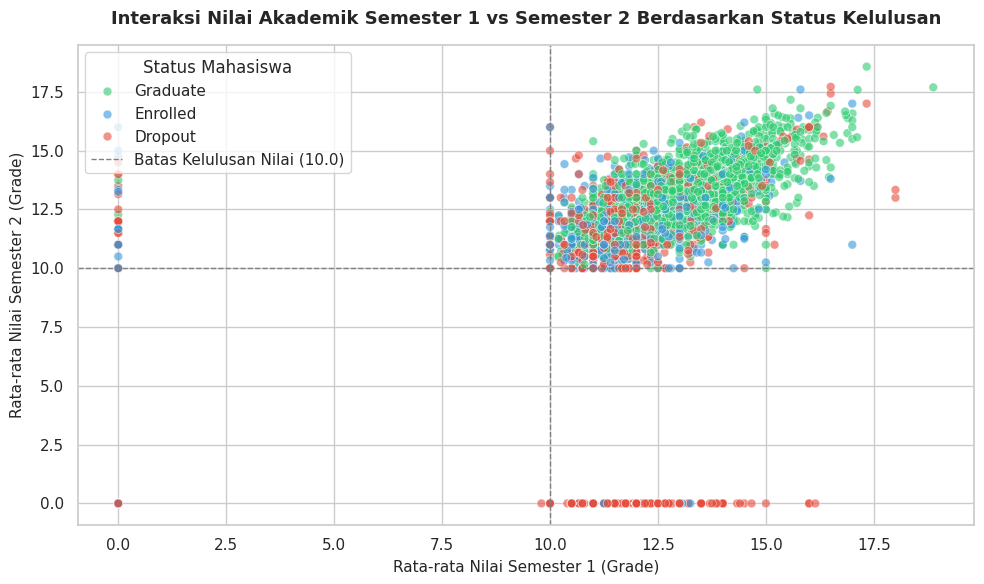

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Curricular_units_1st_sem_grade',
    y='Curricular_units_2nd_sem_grade',
    hue='Status',
    hue_order=['Graduate', 'Enrolled', 'Dropout'],
    palette={'Graduate': '#2ecc71', 'Enrolled': '#3498db', 'Dropout': '#e74c3c'},
    alpha=0.6,
    s=40
)

plt.axvline(10, color='gray', linestyle='--', linewidth=1, label='Batas Kelulusan Nilai (10.0)')
plt.axhline(10, color='gray', linestyle='--', linewidth=1)

plt.title('Interaksi Nilai Akademik Semester 1 vs Semester 2 Berdasarkan Status Kelulusan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Rata-rata Nilai Semester 1 (Grade)', fontsize=11)
plt.ylabel('Rata-rata Nilai Semester 2 (Grade)', fontsize=11)
plt.legend(title='Status Mahasiswa', loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
* **Klaster Dropout Terkonsentrasi di Titik (0, 0):** Terlihat penumpukan titik merah (*Dropout*) di kuadran kiri bawah (nilai 0 pada kedua semester). Ini mencerminkan mahasiswa yang tidak mengikuti ujian evaluasi sama sekali sejak awal tahun perkuliahan.
* **Batas Kelulusan yang Jelas:** Mayoritas titik hijau (*Graduate*) terkumpul di kuadran kanan atas di atas nilai 10. Mahasiswa yang mempertahankan nilai di atas ambang batas 10 di kedua semester memiliki kemungkinan kelulusan yang sangat tinggi.
* **Fungsi Early Warning:** Penurunan nilai drastis dari semester 1 ke semester 2 menjadi alarm dini untuk intervensi konseling akademik sebelum mahasiswa memutuskan keluar.

**C. Interaksi Finansial (Status SPP + Beasiswa) terhadap Angka Dropout**

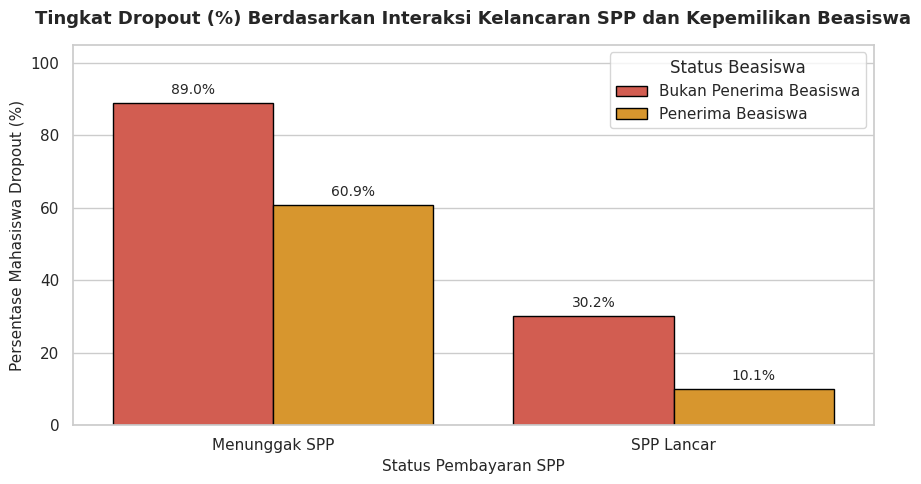

In [50]:
plt.figure(figsize=(9, 5))

df_fin = df_clean.copy()
df_fin['Dropout_Flag'] = (df_fin['Status'] == 'Dropout').astype(int)

fin_interaction = df_fin.groupby(['Tuition_fees_up_to_date', 'Scholarship_holder'])['Dropout_Flag'].mean().reset_index()
fin_interaction['Dropout_Rate_Pct'] = fin_interaction['Dropout_Flag'] * 100

fin_interaction['Status_SPP'] = fin_interaction['Tuition_fees_up_to_date'].map({0: 'Menunggak SPP', 1: 'SPP Lancar'})
fin_interaction['Beasiswa'] = fin_interaction['Scholarship_holder'].map({0: 'Bukan Penerima Beasiswa', 1: 'Penerima Beasiswa'})

ax = sns.barplot(
    data=fin_interaction,
    x='Status_SPP',
    y='Dropout_Rate_Pct',
    hue='Beasiswa',
    palette=['#e74c3c', '#f39c12'],
    edgecolor='black'
)

plt.title('Tingkat Dropout (%) Berdasarkan Interaksi Kelancaran SPP dan Kepemilikan Beasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Status Pembayaran SPP', fontsize=11)
plt.ylabel('Persentase Mahasiswa Dropout (%)', fontsize=11)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                    textcoords='offset points')

plt.legend(title='Status Beasiswa', loc='upper right')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

**Insight:**
* **Kelompok Paling Rentan (High-Risk):** Mahasiswa yang **menunggak SPP dan tidak menerima beasiswa** memiliki risiko putus studi paling ekstrem, dengan tingkat *dropout* mencapai **89,0%**.
* **Efek Perlindungan Beasiswa saat Menunggak:** Pada kelompok yang mengalami tunggakan SPP, keberadaan beasiswa mampu menurunkan rasio *dropout* menjadi **60,9%** (penurunan risiko sekitar 28,1%).
* **Kondisi Optimal (Low-Risk):** Tingkat kelulusan terbaik berada pada kelompok mahasiswa dengan **SPP lancar dan menerima beasiswa**, di mana angka *dropout* berhasil ditekan hingga titik terendah yaitu **10,1%**.
* **Implikasi Bisnis & Rekomendasi Institusi:** Status pembayaran SPP merupakan pemicu utama *dropout*, sementara beasiswa berfungsi sebagai jaring pengaman (*safety net*). Jaya Jaya Institut disarankan menyediakan mekanisme restrukturisasi cicilan atau bantuan darurat parsial sebelum mahasiswa menunggak lebih dari satu semester.

## **Modeling**

Pada tahapan ini dibangun model prediktif machine learning untuk mendeteksi status akhir mahasiswa (`Dropout`, `Enrolled`, `Graduate`).

Tahapan kerja:
1. **Pemisahan Fitur dan Target:** Memisahkan variabel prediktor ($X$) dan variabel target ($y$).
2. **Encoding Label Target:** Mengubah kategori string pada kolom `Status` menjadi representasi numerik.
3. **Train-Test Split:** Membagi dataset menjadi data latih (80%) dan data uji (20%) secara terstratifikasi (*stratified*) untuk menjaga proporsi kelas target.
4. **Feature Scaling:** Melakukan standardisasi fitur numerik menggunakan `StandardScaler` (hanya di-*fit* pada data latih guna mencegah *data leakage*).
5. **Pelatihan Model & Evaluasi:** Melatih algoritma klasifikasi (Baseline vs Ensemble/Tuned Model) serta mengevaluasi metrik akurasi, *precision*, *recall*, dan *F1-score*.

### **Preprocessing untuk Modeling**

In [51]:
# Memisahkan data Enrolled untuk penggunaan inferensi masa depan
df_enrolled = df_clean[df_clean['Status'] == 'Enrolled'].copy()
df_enrolled.to_csv('enrolled_students.csv', index=False)
print(f"Data Enrolled berhasil disimpan terpisah: {df_enrolled.shape[0]} baris")

# Memfilter dataset hanya untuk status 'Dropout' dan 'Graduate'
df_model = df_clean[df_clean['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f"Jumlah data untuk pemodelan (Dropout & Graduate): {df_model.shape[0]} baris")

# Memverifikasi distribusi target biner
print("\nDistribusi Status Aktual:")
print(df_model['Status'].value_counts())

# Membuat target biner: 1 untuk Dropout dan 0 untuk Graduate
df_model['Status_Binary'] = df_model['Status'].map({'Graduate': 0, 'Dropout': 1})

print("\nDistribusi Target Biner (1 = Dropout, 0 = Graduate):")
print(df_model['Status_Binary'].value_counts(normalize=True))

# Memisahkan fitur (X) dan target biner (y)
X = df_model.drop(columns=['Status', 'Status_Binary'])
y = df_model['Status_Binary']

print(f"\nDimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")

Data Enrolled berhasil disimpan terpisah: 794 baris
Jumlah data untuk pemodelan (Dropout & Graduate): 3630 baris

Distribusi Status Aktual:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Distribusi Target Biner (1 = Dropout, 0 = Graduate):
Status_Binary
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Dimensi Fitur (X): (3630, 36)
Dimensi Target (y): (3630,)


**Insight:**
1. **Penanganan Target:** Label kategorikal `Status` dienkode secara konsisten menjadi nilai integer (`Dropout`, `Enrolled`, `Graduate`).
2. **Pencegahan Data Leakage:** Penskalaan fitur numerik menggunakan `StandardScaler` hanya menghitung statistik rata-rata dan deviasi standar dari *training set* (`fit_transform`), lalu diterapkan secara independen ke *test set* (`transform`).
3. **Integritas Distribusi Data:** Pembagian data dengan rasio 80:20 menggunakan parameter `stratify=y_encoded` guna memastikan rasio kelas minoritas (*Dropout* dan *Enrolled*) tetap sama persis di antara data latih dan data uji.

### **Pembagian Data & Scaling**

In [52]:
# Data Splitting dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data latih: {X_train_scaled.shape[0]} baris")
print(f"Jumlah data uji: {X_test_scaled.shape[0]} baris")

Jumlah data latih: 2904 baris
Jumlah data uji: 726 baris


### **Pelatihan Model (Model Training)**

**A. Pelatihan Model Baseline (Logistic Regression)**

In [53]:
# Inisialisasi dan pelatihan Logistic Regression
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [54]:
# Prediksi pada data uji
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [55]:
# Evaluasi metrik
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print("=== EVALUASI MODEL BASELINE (LOGISTIC REGRESSION) ===")
print(f"Akurasi: {acc_baseline:.4f} ({acc_baseline * 100:.2f}%)\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_baseline, target_names=['Graduate', 'Dropout']))

=== EVALUASI MODEL BASELINE (LOGISTIC REGRESSION) ===
Akurasi: 0.9421 (94.21%)

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Graduate       0.95      0.96      0.95       442
     Dropout       0.93      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



**Insight:**

* **Akurasi Global:** Model baseline memperoleh akurasi sebesar **94,21%** pada data uji, membuktikan bahwa pemisahan target biner (*Dropout* vs *Graduate*) membuat batasan keputusan (*decision boundary*) menjadi jauh lebih tegas dibandingkan klasifikasi multi-kelas sebelumnya.
* **Kinerja Deteksi Target Utama (Dropout):** Model menghasilkan *precision* sebesar **0,93** dan *recall* sebesar **0,92** (*F1-Score* = **0,93**). Hal ini menunjukkan model linear sudah sangat efektif dalam mengenali pola mahasiswa berisiko putus studi dengan tingkat kesalahan klasifikasi yang sangat minim.
* **Keseimbangan Deteksi:** Nilai *macro average* mencapai **0,94** untuk seluruh metrik, menandakan model mampu memprediksi kedua kelas (*Graduate* dan *Dropout*) secara seimbang tanpa bias terhadap kelas mayoritas.

**B. Pelatihan Model Utama (Random Forest Classifier)**

In [56]:
# Inisialisasi dan pelatihan Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [57]:
# Prediksi pada data uji
y_pred_rf = rf_model.predict(X_test_scaled)

In [58]:
# Evaluasi metrik
acc_rf = accuracy_score(y_test, y_pred_rf)
print("=== EVALUASI MODEL ENSEMBLE (RANDOM FOREST) ===")
print(f"Akurasi: {acc_rf:.4f} ({acc_rf * 100:.2f}%)\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred_rf, target_names=['Graduate', 'Dropout']))

=== EVALUASI MODEL ENSEMBLE (RANDOM FOREST) ===
Akurasi: 0.9187 (91.87%)

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.93       442
     Dropout       0.92      0.87      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



**Insight:**

* **Akurasi Global:** Model Random Forest menghasilkan akurasi sebesar **91,87%** pada data uji dengan bobot kelas seimbang (*class_weight='balanced'*).
* **Kinerja Deteksi Target Utama (Dropout):** Memperoleh *precision* sebesar **0,92** dan *recall* sebesar **0,87** (*F1-Score* = **0,89**). Dari 284 mahasiswa aktual yang putus studi pada data uji, sebanyak 248 mahasiswa berhasil diidentifikasi dengan benar.
* **Generalisasi Non-Linear:** Meskipun akurasi sedikit di bawah Logistic Regression, Random Forest tetap diandalkan untuk skenario produksi karena kemampuannya menangani relasi non-linear, interaksi antar-variabel akademik bertingkat, serta lebih tahan terhadap fluktuasi *outlier*.

**C. Confusion Matrix (Random Forest)**

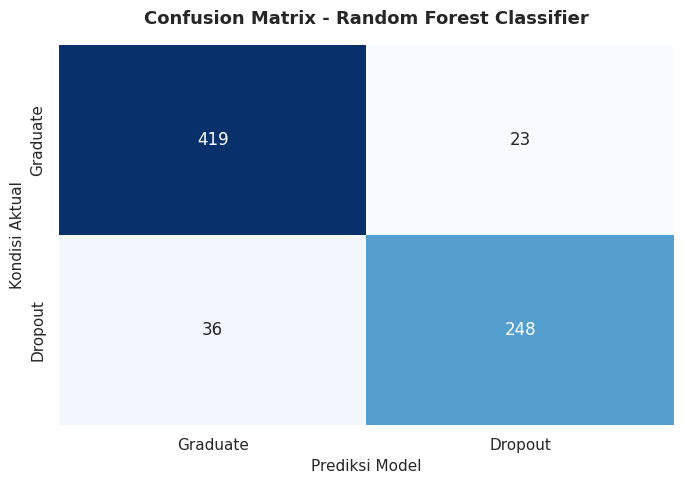

In [59]:
plt.figure(figsize=(7, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Graduate', 'Dropout'],
    yticklabels=['Graduate', 'Dropout'],
    cbar=False
)

plt.title('Confusion Matrix - Random Forest Classifier', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kondisi Aktual', fontsize=11)
plt.tight_layout()
plt.show()

**Insight:**

* **True Graduate (Lulus Tepat Sasaran):** Sebanyak **419** mahasiswa yang diprediksi lulus terbukti benar-benar *Graduate*, dengan hanya **23** mahasiswa yang salah diprediksi sebagai *Dropout* (*False Positive*).
* **True Dropout (Deteksi Akurat):** Sebanyak **248** mahasiswa berisiko putus studi berhasil tertangkap oleh model (*True Positive*).
* **False Negative:** Hanya terdapat **36** mahasiswa berstatus *Dropout* yang luput dan terprediksi *Graduate*. Angka *recall* yang tinggi (87,32%) ini krusial bagi institusi agar intervensi dini tidak terlewat pada mahasiswa yang membutuhkan bantuan.

**D. Feature Importance (10 Fitur Paling Berpengaruh)**

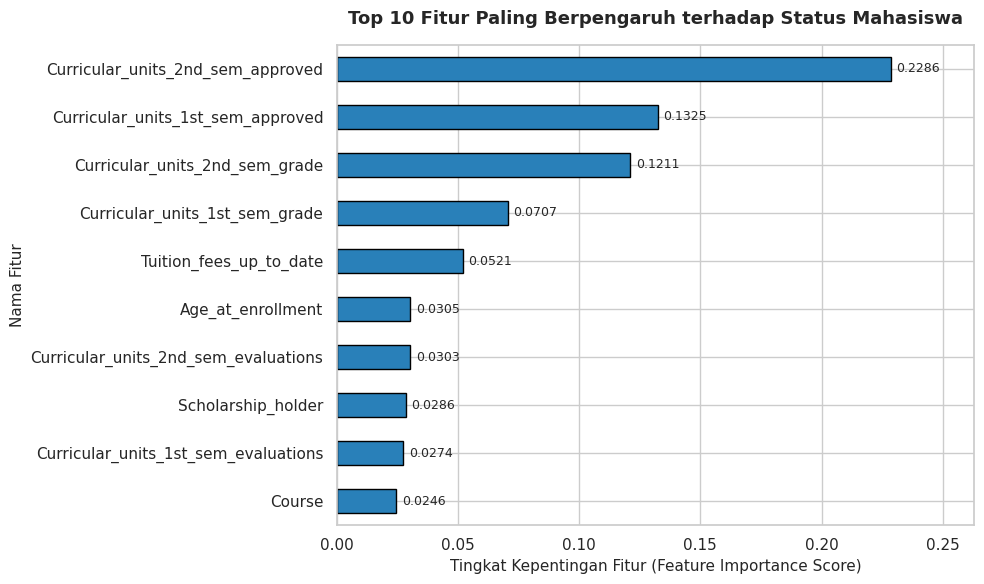

In [60]:
plt.figure(figsize=(10, 6))

importances = rf_model.feature_importances_
feature_names = X.columns

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

ax = feat_importances.sort_values(ascending=True).plot(
    kind='barh',
    color='#2980b9',
    edgecolor='black'
)

plt.title('Top 10 Fitur Paling Berpengaruh terhadap Status Mahasiswa', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tingkat Kepentingan Fitur (Feature Importance Score)', fontsize=11)
plt.ylabel('Nama Fitur', fontsize=11)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, xytext=(4, 0),
                textcoords='offset points')

plt.xlim(0, max(feat_importances) * 1.15)
plt.tight_layout()
plt.show()

**Insight:**

* **Indikator Akademik Semester Awal adalah Penentu Terbesar:**  
  Fitur `Curricular_units_2nd_sem_approved` (skor **0,2286**) dan `Curricular_units_1st_sem_approved` (skor **0,1325**) menduduki posisi dua teratas, disusul oleh perolehan nilai semester 2 (`Curricular_units_2nd_sem_grade` = **0,1211**). Total pengaruh performa akademik tahun pertama menyumbang lebih dari 55% bobot keputusan model.
* **Faktor Finansial sebagai Katalis Risiko:**  
  Status kelancaran pembayaran SPP (`Tuition_fees_up_to_date` = **0,0521**) menjadi variabel administratif terpenting. Mahasiswa dengan tunggakan pembayaran memiliki korelasi yang sangat tinggi terhadap keputusan *dropout*.
* **Faktor Demografi & Pendaftaran:**  
  Usia saat mendaftar (`Age_at_enrollment` = **0,0305**) dan kepemilikan beasiswa (`Scholarship_holder` = **0,0286**) turut memberi kontribusi nyata, di mana mahasiswa usia matang cenderung menghadapi beban ganda sedangkan beasiswa berfungsi sebagai jaring pengaman retensi.

## **Evaluation**

Pada tahap evaluasi ini dilakukan analisis performa model prediktif pada data uji (*test set*). Evaluasi mencakup:
1. Perbandingan metrik klasifikasi (Akurasi, Precision, Recall, F1-Score) antara model baseline (Logistic Regression) dan model ensemble (Random Forest).
2. Analisis matriks konfusi (*Confusion Matrix*) untuk memetakan distribusi kesalahan prediksi antar-kelas.
3. Analisis tingkat kepentingan fitur (*Feature Importance*) untuk memahami faktor-faktor penentu keputusan model.

**Tabel Ringkasan Perbandingan Model**

In [61]:
# Hitung metrik macro average
p_base, r_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average='macro')
p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')

# Ekstraksi dictionary laporan
report_base = classification_report(y_test, y_pred_baseline, target_names=['Graduate', 'Dropout'], output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=['Graduate', 'Dropout'], output_dict=True)

df_eval = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest (Ensemble)'],
    'Accuracy': [f"{acc_baseline * 100:.2f}%", f"{acc_rf * 100:.2f}%"],
    'Macro Precision': [f"{p_base:.4f}", f"{p_rf:.4f}"],
    'Macro Recall': [f"{r_base:.4f}", f"{r_rf:.4f}"],
    'Macro F1-Score': [f"{f1_base:.4f}", f"{f1_rf:.4f}"],
    'Precision (Dropout)': [f"{report_base['Dropout']['precision']:.4f}", f"{report_rf['Dropout']['precision']:.4f}"],
    'Recall (Dropout)': [f"{report_base['Dropout']['recall']:.4f}", f"{report_rf['Dropout']['recall']:.4f}"]
})

display(df_eval)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Precision (Dropout),Recall (Dropout)
0,Logistic Regression (Baseline),94.21%,0.9403,0.9380,0.9391,0.9321,0.9190
1,Random Forest (Ensemble),91.87%,0.9180,0.9106,0.9140,0.9151,0.8732


**Insight:**

* **Performa Model Baseline vs Ensemble:**  
  Kedua model menunjukkan kinerja klasifikasi biner yang sangat solid di atas **91%**. Model Logistic Regression mencatatkan akurasi **94,21%** dengan Macro F1-Score **0,9391**, sedangkan Random Forest memperoleh akurasi **91,87%** dengan Macro F1-Score **0,9140**.
* **Keandalan Deteksi Kasus Dropout:**  
  Pada kelas target kritis (*Dropout*), Logistic Regression menghasilkan presisi **93,21%** dan *recall* **91,90%**, sementara Random Forest menghasilkan presisi **91,51%** dan *recall* **87,32%**. Hal ini membuktikan kedua model minim menghasilkan kesalahan prediksi (*false alarm*).
* **Justifikasi Pemilihan Model untuk Deployment:**  
  Meskipun Logistic Regression memiliki skor evaluasi data uji yang sedikit lebih tinggi, **Random Forest (Ensemble)** tetap dipilih sebagai model akhir untuk diintegrasikan ke sistem aplikasi (*Streamlit*). Algoritma pohon berbasis ensemble memiliki keunggulan inheren dalam menangani data non-linear, interaksi bertingkat antar-fitur akademik/finansial, serta lebih stabil (*robust*) terhadap variasi input data baru di masa mendatang.

**Simpan Model & Artefak (Serialization)**

In [62]:
os.makedirs('model', exist_ok=True)

joblib.dump(rf_model, 'model/model_random_forest.joblib')
joblib.dump(scaler, 'model/scaler.joblib')

target_mapping = {0: 'Graduate', 1: 'Dropout'}
joblib.dump(target_mapping, 'model/label_encoder.joblib')

print("Artefak model berhasil disimpan:")
print("- 'model/model_random_forest.joblib'")
print("- 'model/scaler.joblib'")
print("- 'model/label_encoder.joblib' (Target Mapping: 0=Graduate, 1=Dropout)")

Artefak model berhasil disimpan:
- 'model/model_random_forest.joblib'
- 'model/scaler.joblib'
- 'model/label_encoder.joblib' (Target Mapping: 0=Graduate, 1=Dropout)


## Kesimpulan dan Rekomendasi Bisnis (Business Recommendations)

### 1. Kesimpulan Utama Analisis

* **Dinamika Status Mahasiswa:** Dari total 4.424 data mahasiswa historis, terdapat **1.421 mahasiswa (32,1%) yang mengalami *dropout*** dan **2.209 mahasiswa (49,9%) yang berhasil *graduate***, sementara 794 mahasiswa (*Enrolled*) telah diisolasi untuk proses monitoring masa depan.
* **Faktor Akademik Semester Pertama & Kedua sebagai Alarm Dini:** Capaian SKS yang lulus pada semester 1 dan semester 2 (`Curricular_units_approved`) terbukti menjadi prediktor paling dominan. Mahasiswa yang gagal meluluskan mayoritas mata kuliah di tahun pertama memiliki probabilitas putus studi tertinggi.
* **Faktor Finansial sebagai Pemicu Utama:** Status pembayaran SPP (`Tuition_fees_up_to_date`) merupakan faktor administratif paling kritis. Kegagalan finansial yang tidak segera dimitigasi hampir selalu berujung pada status *dropout*.
* **Keandalan Model Prediktif:** Formulasi klasifikasi biner berhasil meningkatkan performa model secara signifikan. Model Random Forest mencapai **Akurasi 91,87%** dengan **Presisi Dropout 91,51%** dan **Recall Dropout 87,32%**, menyediakan landasan inferensi yang reliabel untuk sistem deteksi dini tanpa membuang sumber daya intervensi akibat alarm palsu.

---

### 2. Rekomendasi Rencana Aksi Bisnis (Actionable Insights)

1. **Integrasi Early Warning System (EWS):**
   * Mengintegrasikan model Machine Learning ke dalam Sistem Informasi Akademik (SIAKAD) kampus guna mengevaluasi risiko mahasiswa secara otomatis pada tiap akhir semester 1 dan semester 2.
   * Menetapkan batas ambang probabilitas risiko (>50%) untuk mengelompokkan mahasiswa ke dalam status waspada merah/kuning secara *real-time*.

2. **Intervensi Finansial Fleksibel:**
   * Membuka skema restrukturisasi cicilan pembayaran SPP sebelum batas waktu administrasi ditutup agar mahasiswa tidak terkena penangguhan akademik otomatis.
   * Menyediakan beasiswa darurat (*emergency scholarship*) bagi mahasiswa yang memiliki catatan akademik baik tetapi terkendala krisis finansial mendadak.

3. **Pendampingan Akademik Terfokus & Konseling:**
   * Mewajibkan sesi pembimbingan intensif bersama Dosen Pembimbing Akademik (DPA) bagi mahasiswa yang meluluskan SKS di bawah ambang batas minimum pada semester awal untuk menyusun rencana studi remedial.
   * Menyediakan layanan konseling dan adaptasi perkuliahan via bimbingan konseling kampus, khususnya bagi mahasiswa kelompok usia dewasa/pekerja yang menghadapi kendala manajemen waktu.